[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch02_workbook.ipynb)

# Probability, surprise and entropy

A word's surprise is the number of bits an optimal code spends on it, and a
rare word costs more bits than a common one. Entropy is the average surprise
of a distribution, and cross-entropy is the average surprise of a model on the
words of a text.

In [1]:
#@title Setup: run this cell first
import math
import os
import re
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

plt.rcParams["axes.formatter.min_exponent"] = 5

MIRROR_REF = "main"
TEXT_URL = f"https://raw.githubusercontent.com/josterri/predicting-the-next-words-notebooks/{MIRROR_REF}/data/pride_and_prejudice.txt"


def load_novel():
    """Pride and Prejudice as lowercase word tokens, one list per chapter."""
    if os.environ.get("PNW_TEXT"):
        text = open(os.environ["PNW_TEXT"], encoding="utf-8").read()
    else:
        try:
            text = urllib.request.urlopen(TEXT_URL).read().decode("utf-8")
        except OSError as e:
            raise RuntimeError(f"The text did not download from {TEXT_URL}: {e}. "
                               "Run this cell again; every cell below needs it.") from None
    chapters = re.split(r"(?m)^CHAPTER [IVXLC]+\.$", text)[1:]
    return [re.findall(r"[a-z]+(?:'[a-z]+)*", c.lower().replace("’", "'")) for c in chapters]


# The words of a typed text, split by the regular expression that splits the novel;
# with one=True, its only word.
def words_of(text, one=False):
    w = re.findall(r"[a-z]+(?:'[a-z]+)*", text.lower().replace("’", "'"))
    assert w, f"{'WORD' if one else 'SENTENCE'} holds no word: type one between the quotes"
    assert not one or len(w) == 1, (f'"{text}" is {len(w)} words to the tokeniser, {" and ".join(w)}: it splits '
                                    "a word at a hyphen, an accented letter and every mark but a to z and the apostrophe")
    return w[0] if one else w


# A word's probability under the unigram model of the training chapters, and its surprise in bits.
def surprise(word):
    p = counts[word] / len(train)
    return p, -math.log2(p) if p else math.inf


# Bars of surprises in bits. An unseen word's surprise is infinite: its bar is hatched, marked ∞
# and stands at a fixed 1.2 times the tallest finite bar. Past 30 words, five words are named
# at 8 points, the most surprising first, each far enough from the others to be read.
def surprise_bars(ax, words, s, values):
    n, top = len(s), max([x for x in s if x < math.inf], default=8)
    unseen, named, gap = [x == math.inf for x in s], [], 1 if n <= 30 else -(-n // 45)
    bars = ax.bar(range(n), [1.2 * top if u else x for u, x in zip(unseen, s)], color="tab:blue")
    for b in (b for b, u in zip(bars, unseen) if u):
        b.set(hatch="//", facecolor="white", edgecolor="tab:red")
    ax.bar_label(bars, ["∞" if u else f"{x:.2f}" if values else "" for u, x in zip(unseen, s)],
                 fontsize=min(9, 380 / n), padding=2, bbox=dict(fc="white", ec="none", pad=0.5))
    for i in sorted(range(n), key=lambda i: -s[i]):
        if len(named) < (n if n <= 30 else 5) and all(abs(i - j) >= gap for j in named):
            named.append(i)
    ax.set_xticks(named, [words[i] for i in named], rotation=0 if n <= 3 else 90, fontsize=10 if n <= 30 else 8)
    ax.set(ylabel="surprise (bits)", ylim=(0, 1.35 * top),
           xlabel="word" if n <= 30 else "word, five of the most surprising named")


# Each word's probability and its surprise, as two panels of bars.
def show_words(words):
    p, s = zip(*map(surprise, words))
    fig, (a, b) = plt.subplots(1, 2, figsize=(6, 3.5), layout="constrained")
    a.bar_label(a.bar(range(len(p)), p), [f"{x:.3g}" for x in p], fontsize=8)
    a.set(ylabel="probability in the training chapters", ylim=(0, 1.15 * (max(p) or 1)),
          xticks=range(len(p)), xticklabels=words, xlabel="word")
    surprise_bars(b, words, s, True)
    plt.show()


# A fair die, and a loaded die whose every side comes up half as often as the side before it.
def dice(sides):
    assert isinstance(sides, int) and 1 <= sides <= 100, "SIDES must be a whole number from 1 to 100"
    loaded = 0.5 ** np.arange(1, sides + 1)
    return np.full(sides, 1 / sides), loaded / loaded.sum()


# H(P, Q) in bits, the surprise under Q averaged over outcomes drawn from P; H(P) is H(P, P).
def cross_entropy(p, q):
    return float((p * np.log2(1 / q)).sum())


# D(P ‖ Q) in bits.
def kl(p, q):
    return float((p * np.log2(p / q)).sum())


# The probability of each side, and the entropy of each die, as bars.
def show_dice(sides):
    fair, loaded = dice(sides)
    h = [cross_entropy(fair, fair), cross_entropy(loaded, loaded)]
    fig, (a, b) = plt.subplots(1, 2, figsize=(6, 3.5), width_ratios=(3, 2), layout="constrained")
    a.bar(np.arange(1, len(fair) + 1), loaded, color="tab:orange", ec="tab:orange", label="loaded")
    a.hlines(1 / sides, 0.5, sides + 0.5, colors="black", linestyles="--", label="fair")
    a.set(xlabel="side", ylabel="probability")
    a.xaxis.set_major_locator(plt.MaxNLocator(10, integer=True, steps=[1, 2, 5, 10], min_n_ticks=1))
    a.legend(loc="lower center", bbox_to_anchor=(0.5, 1), ncol=2, frameon=False)
    b.bar_label(b.bar(["fair", "loaded"], h, color=["white", "tab:orange"], ec="black"), fmt="%.3f", fontsize=8)
    b.set(ylabel="entropy (bits)", ylim=(0, 1.15 * max(h[0], 0.1)))
    plt.show()


# Each word's surprise in reading order, and a dashed line at their mean.
def show_sentence(sentence):
    w = words_of(sentence)
    s = [surprise(x)[1] for x in w]
    m = float(np.mean(s))
    fig, ax = plt.subplots(figsize=(6, 3.5), layout="constrained")
    surprise_bars(ax, w, s, len(w) <= 12)
    ax.axhline(m if m < math.inf else np.nan, color="black", linestyle="--",
               label=f"mean, {m:.2f} bits per word" if m < math.inf else "mean: infinite")
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), frameon=False)
    plt.show()


# Held-out cross-entropy in bits per token of the unigram model over the size − 1 commonest
# training words and <unk>.
def heldout(size):
    keep = {w for w, _ in counts.most_common(size - 1)}
    unk = len(train) - sum(counts[w] for w in keep)
    return float(np.mean([math.log2(len(train) / (counts[w] if w in keep else unk)) for w in test]))


# Unigram models P and Q of the novel's two halves, over the size − 1 commonest words found in
# both halves and <unk>, so that every probability is above 0.
def half_models(size):
    most = len(both) + 1
    assert isinstance(size, int) and 1 <= size <= most, f"V must be a whole number from 1 to {most:,}"
    keep = both[:size - 1]
    return [np.array([c[w] for w in keep] + [n - sum(c[w] for w in keep)]) / n for c, n in halves]


chapters = load_novel()
n_train = round(0.9 * len(chapters))
train, test = ([w for c in part for w in c] for part in (chapters[:n_train], chapters[n_train:]))
counts, novel = Counter(train), train + test
halves = [(Counter(x), len(x)) for x in (novel[:len(novel) // 2], novel[len(novel) // 2:])]
both = [w for w, _ in Counter(novel).most_common() if halves[0][0][w] and halves[1][0][w]]
display(Markdown(f"{len(chapters)} chapters: the first {n_train} train the unigram model, with {len(train):,} "
                 f"tokens and {len(counts):,} word types; the last {len(chapters) - n_train} test it."))

61 chapters: the first 55 train the unigram model, with 110,030 tokens and 6,102 word types; the last 6 test it.

## 1. A rare word costs more bits than a common one

The unigram model gives each word its share of the tokens of the training
chapters, and a word the training chapters lack has infinite surprise. The
chart draws that surprise as a hatched bar marked ∞, whose height is no value.
Run the cell, then put a word of your own into `WORD`: how many times likelier
is it than "pemberley", and how many bits apart are their surprises?

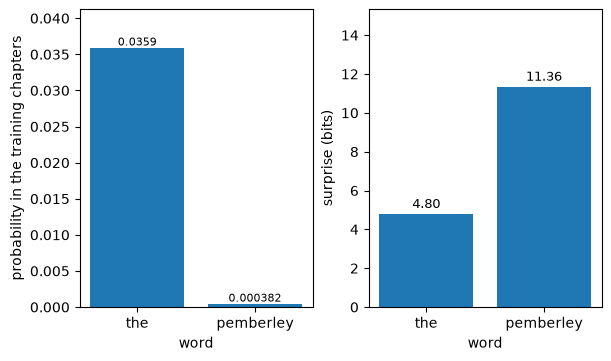

In [2]:
WORD = "the"
show_words([words_of(WORD, one=True), "pemberley"])

### Solution

In [3]:
w = words_of(WORD, one=True)
(p, s), (q, t) = surprise(w), surprise("pemberley")
display(Markdown(
    f'The training chapters lack "{w}": its probability is {p:g}, its surprise infinite.' if not p else
    f'"{w}" is as likely as "pemberley", {q:.3g}; their surprises differ by {abs(t - s):.2f} bits.' if p == q else
    f'"{w}" has probability {p:.3g} and a surprise of {s:.2f} bits, "pemberley" {q:.3g} and {t:.2f}. '
    f"The likelier word is {max(p / q, q / p):.3g} times as likely, and their surprises differ by "
    f"{abs(t - s):.2f} bits, the log₂ of that ratio: each halving of a probability adds one bit."))

"the" has probability 0.0359 and a surprise of 4.80 bits, "pemberley" 0.000382 and 11.36. The likelier word is 93.9 times as likely, and their surprises differ by 6.55 bits, the log₂ of that ratio: each halving of a probability adds one bit.

## 2. A fair die has the most entropy of any die with as many sides

The loaded die comes up on each side half as often as on the side before it.
Run the cell, then set `SIDES` to another count: which die is harder to
predict, and by how many bits?

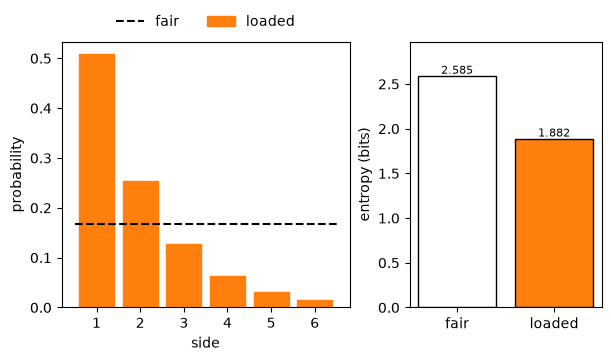

In [4]:
SIDES = 6
show_dice(SIDES)

### Solution

In [5]:
hf, hl = (cross_entropy(d, d) for d in dice(SIDES))
display(Markdown(
    f"A die with one side always lands on it: both dice have entropy {hf:.0f} bits." if SIDES == 1 else
    f"The fair die's entropy is {hf:.3f} bits, log₂ {SIDES}, the most a die with {SIDES} sides can "
    f"have. The loaded die's is {hl:.3f} bits: the fair die is {hf - hl:.3f} bits harder to predict."))

The fair die's entropy is 2.585 bits, log₂ 6, the most a die with 6 sides can have. The loaded die's is 1.882 bits: the fair die is 0.703 bits harder to predict.

## 3. A sentence's mean surprise is the model's cross-entropy on it

The unigram model's cross-entropy on a sentence, in bits per word, is the mean
of its surprise at each word. A word the training chapters lack has infinite
surprise and makes the mean infinite; its hatched bar, marked ∞, stands above
the tallest finite bar at a height that is no value. Run the cell, then put a
sentence of your own into `SENTENCE`: which word surprises the model most, and
what is the mean?

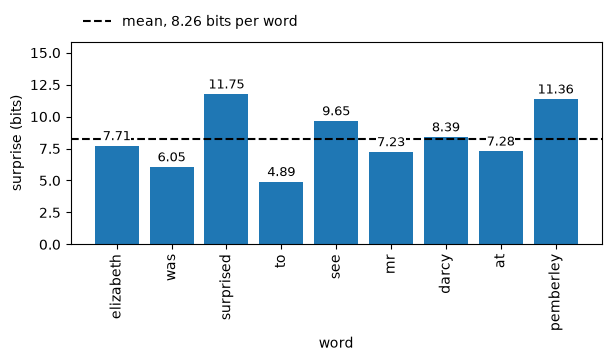

In [6]:
SENTENCE = "elizabeth was surprised to see mr darcy at pemberley"
show_sentence(SENTENCE)

### Solution

In [7]:
w = words_of(SENTENCE)
s = [surprise(x)[1] for x in w]
unseen = ", ".join(f'"{x}"' for x in dict.fromkeys(x for x, y in zip(w, s) if y == math.inf))
display(Markdown(
    f"The training chapters lack {unseen}: each surprise is infinite, and so is the mean." if unseen else
    f'"{w[int(np.argmax(s))]}" surprises the model most, at {max(s):.2f} bits. The mean, '
    f"{np.mean(s):.2f} bits per word, is the unigram model's cross-entropy on the sentence."))

"surprised" surprises the model most, at 11.75 bits. The mean, 8.26 bits per word, is the unigram model's cross-entropy on the sentence.

## Appendix. Cross-entropy and perplexity on held-out chapters

A model Q gives the word w the probability Q(w), and the word's surprise is

s(w) = −log₂ Q(w) bits.

Entropy is the surprise a distribution P expects of its own outcomes, and
cross-entropy is the mean surprise of a model Q on outcomes drawn from P:

H(P) = −Σ P(x) log₂ P(x),   H(P, Q) = −Σ P(x) log₂ Q(x) ≥ H(P).

On N held-out tokens w₁ … w_N the mean surprise estimates the cross-entropy,
and perplexity is two to its power:

Ĥ = −(1/N) · Σ log₂ Q(wᵢ),   PP = 2^Ĥ.

The uniform model gives each of V words the probability 1/V, so Ĥ = log₂ V and
PP = V. The unigram model keeps the V − 1 commonest words of the training
chapters and counts every other word as `<unk>`. A smaller V merges more words
into `<unk>` and lowers the perplexity of the same text, so a perplexity
compares models only on one test set, one vocabulary and one tokeniser.

Held-out cross-entropy on the last chapters, with two to its power, the
perplexity, on the right axis, for V from 10 to the full vocabulary of the
training chapters:

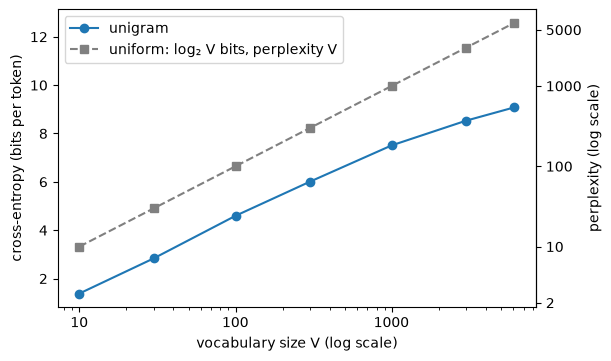

In [8]:
grid = [10, 30, 100, 300, 1000, 3000, len(counts)]
h = [heldout(v) for v in grid]
fig, ax = plt.subplots(figsize=(6, 3.5), layout="constrained")
ax.plot(grid, h, "o-", label="unigram")
ax.plot(grid, np.log2(grid), "s--", color="gray", label="uniform: log₂ V bits, perplexity V")
ax.set(xscale="log", xlabel="vocabulary size V (log scale)", ylabel="cross-entropy (bits per token)")
right = ax.secondary_yaxis("right", functions=(np.exp2, lambda y: np.log2(np.maximum(y, 1e-300))))
right.set(ylabel="perplexity (log scale)", yticks=[2, 10, 100, 1000, 5000])
ax.legend(loc="upper left")
plt.show()

**Exercise.** The KL divergence D(P ‖ Q) is the excess of cross-entropy over
entropy:

D(P ‖ Q) = Σ P(x) log₂ (P(x) / Q(x)) = H(P, Q) − H(P).

P and Q are the unigram models of the first and the second half of the novel,
over the V − 1 commonest words found in both halves and `<unk>`: a word missing
from one half would make one direction infinite. Set `V` to 10, 100, 1,000 and
3,000 in turn and rerun the cell. Is D(P ‖ Q) equal to D(Q ‖ P)?

In [9]:
V = 100

p, q = half_models(V)
print(f"V = {V:,}: D(P ‖ Q) = {kl(p, q):.4g} bits, D(Q ‖ P) = {kl(q, p):.4g} bits")

V = 100: D(P ‖ Q) = 0.01363 bits, D(Q ‖ P) = 0.01271 bits


### Solution

In [10]:
tried = [1, 10, 100, 1000, 3000]
for v in tried:
    p, q = half_models(v)
    f, r = kl(p, q), kl(q, p)
    print(f"V = {v:>5,}: D(P ‖ Q) = {f:.4g} bits, D(Q ‖ P) = {r:.4g} bits, "
          f"{abs(f - r) / max(f, r) if f != r else 0:.2%} apart")
display(Markdown(
    f"At V = {v:,}, D(P ‖ Q) is {f:.4f} bits and D(Q ‖ P) {r:.4f}: one pair of models gives two divergences. "
    f"D(P ‖ Q) is H(P, Q) − H(P) = {cross_entropy(p, q):.4f} − {cross_entropy(p, p):.4f}, the extra bits "
    "the second half's model spends on the first half's words."))

V =     1: D(P ‖ Q) = 0 bits, D(Q ‖ P) = 0 bits, 0.00% apart
V =    10: D(P ‖ Q) = 0.0009379 bits, D(Q ‖ P) = 0.0009389 bits, 0.11% apart
V =   100: D(P ‖ Q) = 0.01363 bits, D(Q ‖ P) = 0.01271 bits, 6.74% apart
V = 1,000: D(P ‖ Q) = 0.07935 bits, D(Q ‖ P) = 0.07359 bits, 7.26% apart
V = 3,000: D(P ‖ Q) = 0.1191 bits, D(Q ‖ P) = 0.1141 bits, 4.21% apart


At V = 3,000, D(P ‖ Q) is 0.1191 bits and D(Q ‖ P) 0.1141: one pair of models gives two divergences. D(P ‖ Q) is H(P, Q) − H(P) = 8.7149 − 8.5958, the extra bits the second half's model spends on the first half's words.